## Сравнение: Логистическая регрессия с $L_2$-регуляризацией

В данном эксперименте исследуется эффективность адаптивного чебышёвского шага на задаче классификации. BCE логистической регрессии $L_2$ регуляризацией является сильно выпулкой функцией с константой сильной выпуклости $\mu$.

### Здача - минимзация функционала, известного как BCE (бинарная кросс-энтропия)
$$f(w) = \frac{1}{n} \sum_{i=1}^n \ln(1 + e^{-y_i x_i^T w}) + \frac{\mu}{2}\|w\|_2^2$$


### Сравниваемые методы
1.  **Градиентный спуск (GD):** Использует константный шаг $\eta = 1/L_{global}$, где $L_{global}$ — теоретическая верхняя граница спектра Гессиана во всем пространстве.
2.  **Адаптивный метод:**
    *   На каждой итерации  вычисляется **локальная константа Липшица** $L_{loc}$ через максимальное собственное число текущего Гессиана: $H(w) = \frac{1}{n} X^T D(w) X + \mu I$.
    *   Применяется оптимальный шаг $\frac{2}{\mu + L_{loc}}$, учитывающий текущую кривизну ландшафта.


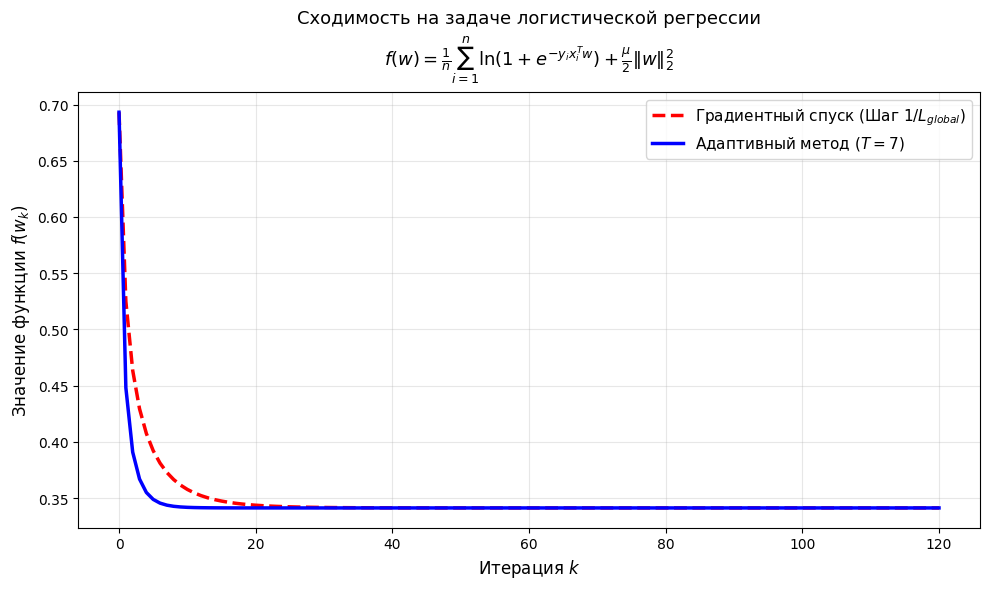

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Генерация данных
n_samples, n_features = 200, 20
# Признаки разного масштаба для неровности рельефа функции
scales = np.linspace(1, 10, n_features)
X = np.random.randn(n_samples, n_features) * scales
func_formula = r'$f(w) = \frac{1}{n} \sum_{i=1}^n \ln(1 + e^{-y_i x_i^T w}) + \frac{\mu}{2}\|w\|_2^2$'
w_true = np.random.randn(n_features)
y = np.sign(X @ w_true + np.random.randn(n_samples) * 0.5)

mu_reg = 1.0  # Коэффициент сильной выпуклости (mu)


#  Определяем функцию, градиент и Гессиан ---
def f(w):
    margins = -y * (X @ w)
    loss = np.mean(np.log1p(np.exp(np.clip(margins, -50, 50))))
    return loss + 0.5 * mu_reg * np.linalg.norm(w) ** 2


def grad(w):
    # Градиент
    sigm = 1 / (1 + np.exp(np.clip(y * (X @ w), -50, 50)))
    g = - (X.T @ (y * sigm)) / n_samples
    return g + mu_reg * w


def local_L(w):
    # Максимальное собственное число локального Гессиана
    preds = 1 / (1 + np.exp(np.clip(-(X @ w), -50, 50)))
    D = preds * (1 - preds)
    # Формула Гессиана лог. регрессии: (X^T D X) / n + mu * I
    H = (X.T * D) @ X / n_samples + mu_reg * np.eye(n_features)
    return np.linalg.eigvalsh(H)[-1]


# Глобальная константа L (максимально возможная кривизна, когда p=0.5)
L_global = np.linalg.norm(X, ord=2) ** 2 / (4 * n_samples) + mu_reg
mu_global = mu_reg

T = 1
total_iters = 120
w0 = np.zeros(n_features)

# Обычный ГД со строго гарантированным шагом 1/L
w_gd = w0.copy()
f_gd = [f(w_gd)]
lr_gd = 1.0 / L_global

for _ in range(total_iters):
    w_gd = w_gd - lr_gd * grad(w_gd)
    f_gd.append(f(w_gd))

# Адаптивный Чебышёв
w_ch = w0.copy()
f_ch = [f(w_ch)]

for cycle in range(total_iters // T):
    L_loc = local_L(w_ch)

    nodes = np.cos((2 * np.arange(1, T + 1) - 1) * np.pi / (2 * T))
    roots = 0.5 * (L_loc + mu_global) + 0.5 * (L_loc - mu_global) * nodes
    steps = 1 / roots

    for alpha in steps:
        w_ch = w_ch - alpha * grad(w_ch)
        f_ch.append(f(w_ch))

plt.figure(figsize=(10, 6))
plt.plot(f_gd, 'r--', label='Градиентный спуск (Шаг $1/L_{global}$)', linewidth=2.5)
plt.plot(f_ch, 'b-', label='Адаптивный метод', linewidth=2.5)

plt.xlabel('Итерация $k$', fontsize=12)
plt.ylabel('Значение функции $f(w_k)$', fontsize=12)
plt.title(f'Сходимость на задаче логистической регрессии\n{func_formula}', fontsize=13, pad=20)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()